Exploración descriptiva de los datos, para preparar el preprocesamiento

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

# Load
path = "../data/raw/HousingData.csv"
df = pd.read_csv(path)
print("shape:", df.shape)
display(df.head())

shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [237]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [201]:
eda_config = {
    "feature_processing": {
        "handling_na":{                    
            "mean": [],
            "median": [],
            "most_frequent": [],
            "no_action": []
        },
        "handling_outliers": {
            "remove": [],
            "log_transform": [],
            "capping_iqr": [],
            "capping_winsor": [],
            "no_action": []
        },
        "handling_correlated_features": {
            "remove": [],
            "no_action": []
        },        
        "scaler": "RobustScaler"
    },
    "model_selection": {  
        "candidates": []
     }}


##  Análisis duplicados y valores nulos

In [202]:
# Duplicated rows
dupes = df.duplicated().sum()
print("duplicated rows:", dupes)

duplicated rows: 0


In [203]:
# Basic info & missing
# Conteo de nulos por columna
print("\n--- Null counts (per column) ---")
null_counts = df.isnull().sum().sort_values(ascending=False)
display(null_counts[null_counts > 0])


missing = df.isnull().mean().sort_values(ascending=False)
print("\n--- Missing (%) ---")
display(missing[missing > 0])



--- Null counts (per column) ---


CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64


--- Missing (%) ---


CRIM     0.039526
ZN       0.039526
INDUS    0.039526
CHAS     0.039526
AGE      0.039526
LSTAT    0.039526
dtype: float64

In [204]:
cols_no_missing = df.columns[df.isnull().sum() == 0].tolist()
for col in cols_no_missing:
    eda_config["feature_processing"]["handling_na"]["no_action"].append(col)


## Análisis imputación valores nulos

In [205]:
"Auxiliar function to analyze the distribution of a numerical variable in a DataFrame and plot its histogram with quartile lines."
def analyze_distribution(df, column, bins=30):
    series = df[column].dropna()
    
    q1 = series.quantile(0.25)
    q2 = series.quantile(0.50)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    print(f"Variable: {column}")
    print(f"Type: {series.dtype}")    
    print(f"Q1 (25%): {q1:.3f}")
    print(f"Median (50%): {q2:.3f}")
    print(f"Q3 (75%): {q3:.3f}")
    print(f"IQR: {iqr:.3f}")
    
    plt.figure()
    series.plot(
        kind='hist',
        bins=bins,
        title=f'{column} distribution',
        alpha=0.7
    )
    
    plt.axvline(q1, linestyle='--', label='Q1')
    plt.axvline(q2, linestyle='-', label='Median')
    plt.axvline(q3, linestyle='--', label='Q3')
    
    plt.legend()
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


Antes de analizar la distribución numérica de la variable, tenemos que entender de qué se trata cada una de ellas, para poder elegir la manera correcta de imputar.

### CRIM: Per capita crime rate by town.

Variable: CRIM
Type: float64
Q1 (25%): 0.082
Median (50%): 0.254
Q3 (75%): 3.560
IQR: 3.478


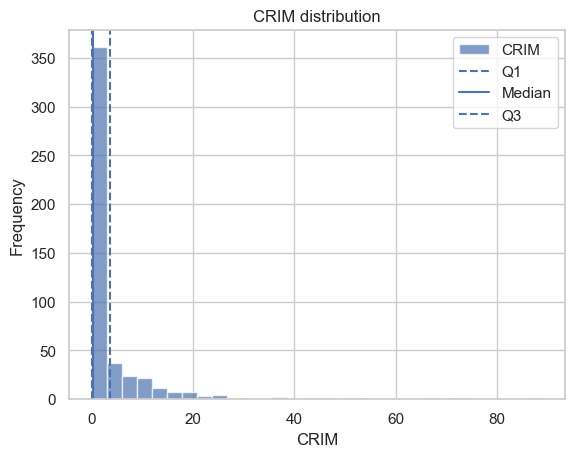

In [206]:
analyze_distribution(df, 'CRIM')

Se imputará la variable 'CRIM' con la mediana: el histograma muestra una distribución sesgada y un rango intercuartílico (IQR) amplio, por lo que la mediana —al ser más robusta frente a valores atípicos y asimetrías— es una medida de tendencia central más adecuada que la media para la imputación.

In [207]:
eda_config["feature_processing"]["handling_na"]["median"].append('CRIM')

### ZN: Proportion of residential land zoned for large lots (over 25,000 sq.ft).This indicates a wealthy, spacious area

Variable: ZN
Type: float64
Q1 (25%): 0.000
Median (50%): 0.000
Q3 (75%): 12.500
IQR: 12.500


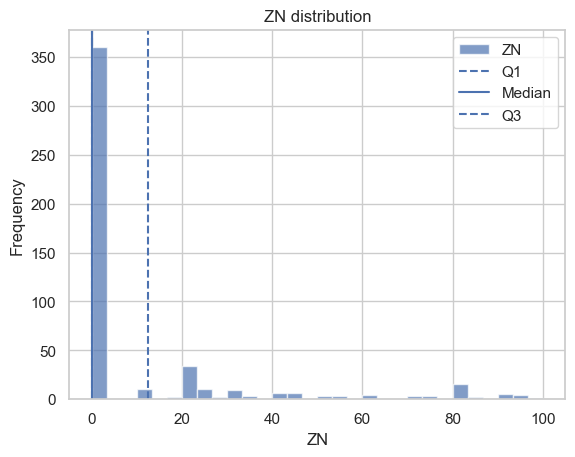

In [208]:
analyze_distribution(df, 'ZN')

Se imputa la variable 'ZN' con la mediana: el histograma muestra una distribución sesgada y un IQR amplio, por lo que la mediana —al ser más robusta frente a valores atípicos y asimetrías— es más adecuada que la media para la imputación.


In [209]:
eda_config["feature_processing"]["handling_na"]["median"].append('ZN')

### "INDUS": Proportion of non-retail business acres per town.

Variable: INDUS
Type: float64
Q1 (25%): 5.190
Median (50%): 9.690
Q3 (75%): 18.100
IQR: 12.910


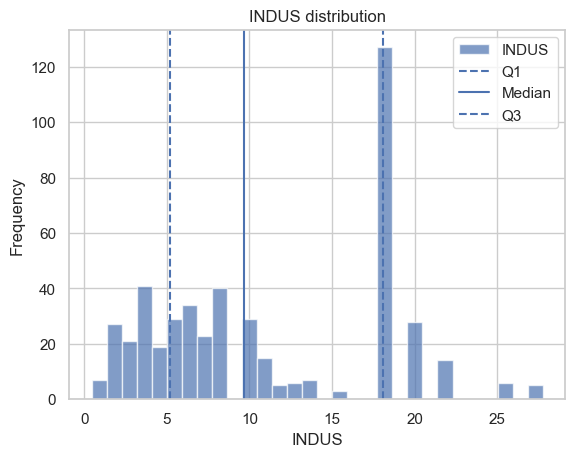

In [210]:
analyze_distribution(df, 'INDUS')

Se imputará la variable 'INDUS' con la mediana: el histograma muestra una distribución con ligera asimetría y colas, además de un rango intercuartílico (IQR) relativamente amplio, por lo que la mediana —al ser más robusta frente a valores atípicos y asimetrías— es una medida de tendencia central más adecuada que la media para la imputación.

In [211]:
eda_config["feature_processing"]["handling_na"]["median"].append('INDUS')

### "CHAS": Charles River dummy variable.


Variable: CHAS
Type: float64
Q1 (25%): 0.000
Median (50%): 0.000
Q3 (75%): 0.000
IQR: 0.000


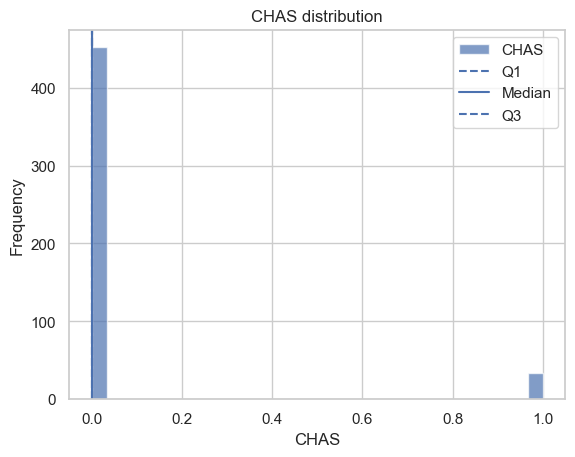

In [212]:
analyze_distribution(df, 'CHAS')

CHAS es una variable dummy (binaria) que indica si una parcela limita con el río Charles (1 = sí, 0 = no).Dado el marcado desequilibrio de clases y la baja proporción de valores faltantes (~3.95%), la estrategia más razonable es imputar por la moda o mediana (0) para preservar la distribución observada y minimizar la introducción de ruido.



In [213]:
eda_config["feature_processing"]["handling_na"]["most_frequent"].append('CHAS')

### "AGE": Proportion of owner-occupied units built prior to 1940.

Variable: AGE
Type: float64
Q1 (25%): 45.175
Median (50%): 76.800
Q3 (75%): 93.975
IQR: 48.800


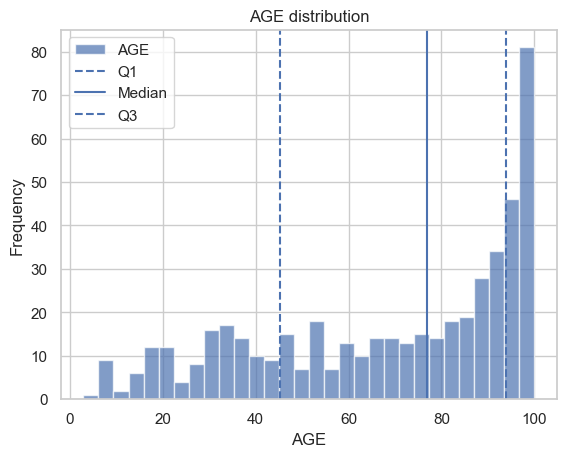

In [214]:
analyze_distribution(df, 'AGE')

Se imputará la variable 'AGE' con la mediana: el histograma muestra una distribución sesgada y un rango intercuartílico (IQR) considerable, por lo que la mediana —al ser más robusta frente a valores atípicos y asimetrías— es una medida de tendencia central más adecuada que la media para la imputación.

In [215]:
eda_config["feature_processing"]["handling_na"]["median"].append('AGE')

### "LSTAT": % lower status of the population.

Variable: LSTAT
Type: float64
Q1 (25%): 7.125
Median (50%): 11.430
Q3 (75%): 16.955
IQR: 9.830


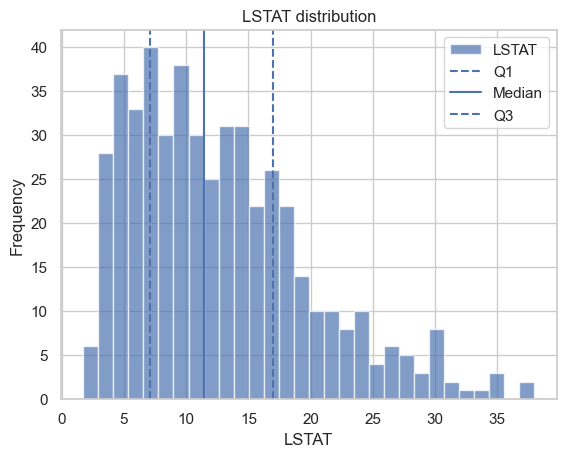

In [216]:
analyze_distribution(df, 'LSTAT')

Se imputará la variable 'AGE' con la mediana: el histograma muestra una distribución sesgada por lo que la mediana —al ser más robusta frente a valores atípicos y asimetrías— es una medida de tendencia central más adecuada que la media para la imputación.

In [217]:
eda_config["feature_processing"]["handling_na"]["median"].append('LSTAT')

## Análisis outliers

In [218]:
def outlier_analysis_boxplots(variables):
    # Boxplots para variables seleccionadas y resumen breve de outliers

    # Configuramos el layout para que sea más ancho y quepan los textos
    fig, axes = plt.subplots(1, len(variables), figsize=(5 * len(variables), 6))
    plt.subplots_adjust(wspace=0.4) # Espacio entre gráficas

    for i, col in enumerate(variables):
        ax = axes[i] if len(variables) > 1 else axes
        series = df[col].dropna()
        
        # 1.Dibujar Boxplot
        series.plot.box(ax=ax, vert=True, patch_artist=True, 
                        boxprops=dict(facecolor='lightblue', color='blue'))
        
        # 2.Calcular estadísticos clave
        desc = series.describe()
        q1, q3 = desc['25%'], desc['75%']
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        lower_bound = q1 - 1.5 * iqr
        outliers_count = ((series < lower_bound) | (series > upper_bound)).sum()

        # 3.Crear el texto informativo
        stats_text = (
            f"Media: {desc['mean']:.2f}\n"
            f"Mediana: {desc['50%']:.2f}\n"
            f"Std Dev: {desc['std']:.2f}\n"
            f"Outliers: {outliers_count}"
        )

        # 4.Insertar el texto en el gráfico (posición superior derecha)
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_title(f'Análisis de {col}', fontweight='bold')
        ax.set_ylabel('Valor')

    plt.tight_layout()
    plt.show()




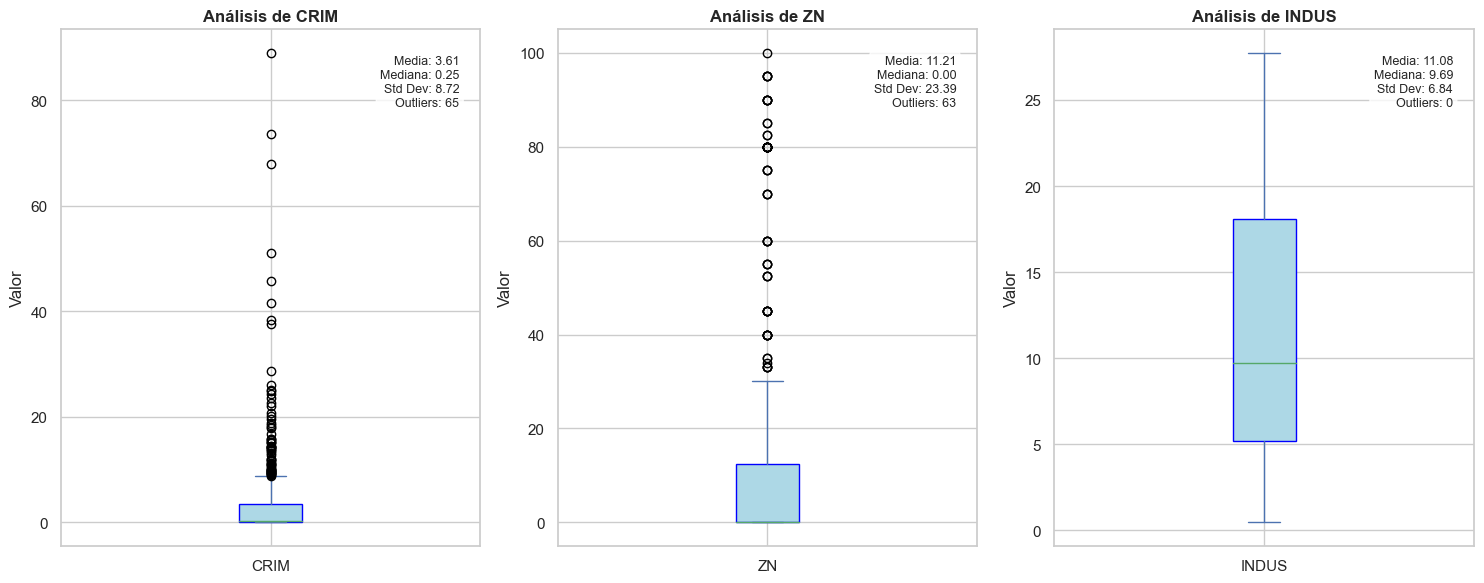

In [219]:
variables = ['CRIM', 'ZN', 'INDUS']
outlier_analysis_boxplots(variables)

| Variable | Tipo de Outlier | Estrategia Recomendada en Pipeline |
|---|---:|---|
| CRIM | Valor extremo real (sesgo) | Transformación logarítmica (np.log1p) |
| ZN   | Valor extremo real (sesgo) | Transformación logarítmica (np.log1p) |


In [220]:
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("INDUS")
eda_config["feature_processing"]["handling_outliers"]["log_transform"].append("CRIM")
eda_config["feature_processing"]["handling_outliers"]["log_transform"].append("ZN")

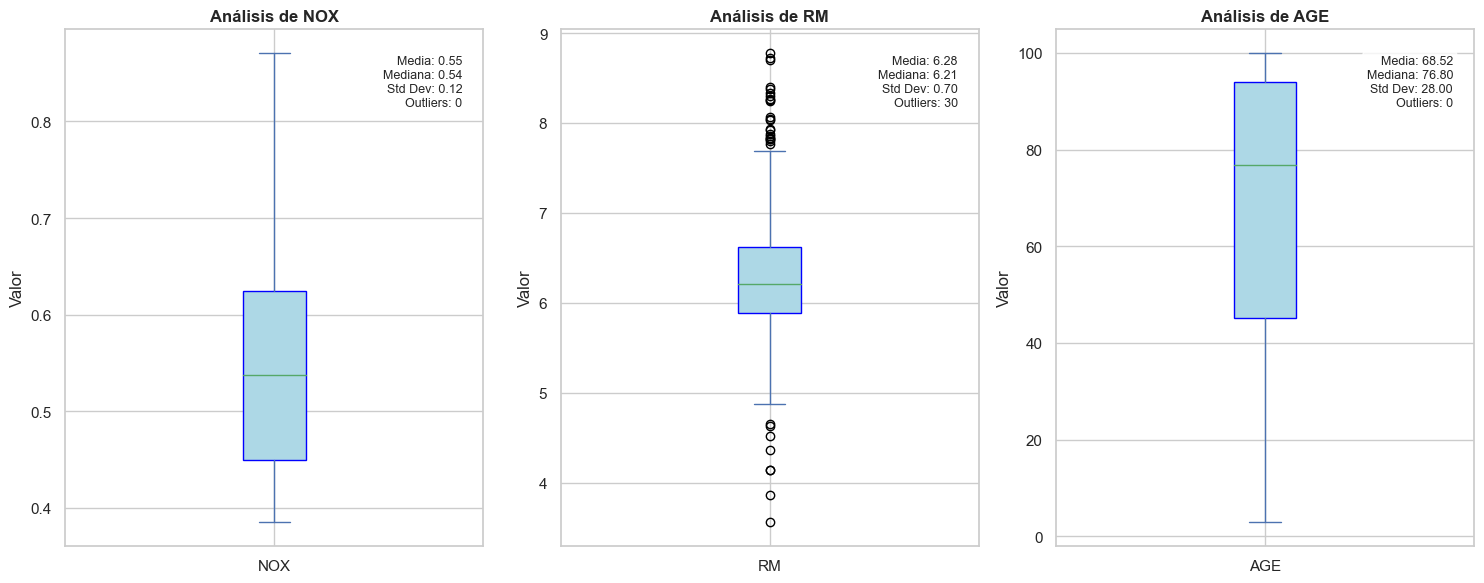

In [221]:
variables = ['NOX', 'RM', 'AGE']
outlier_analysis_boxplots(variables)

| Variable | Tipo de Outlier | Estrategia Recomendada en Pipeline |
|---|---:|---|
| RM | Valor extremo real (simétrico) | Capping en límites 1.5 IQR o RobustScaler |

In [222]:
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("NOX")
eda_config["feature_processing"]["handling_outliers"]["capping_iqr"].append("RM")
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("AGE")

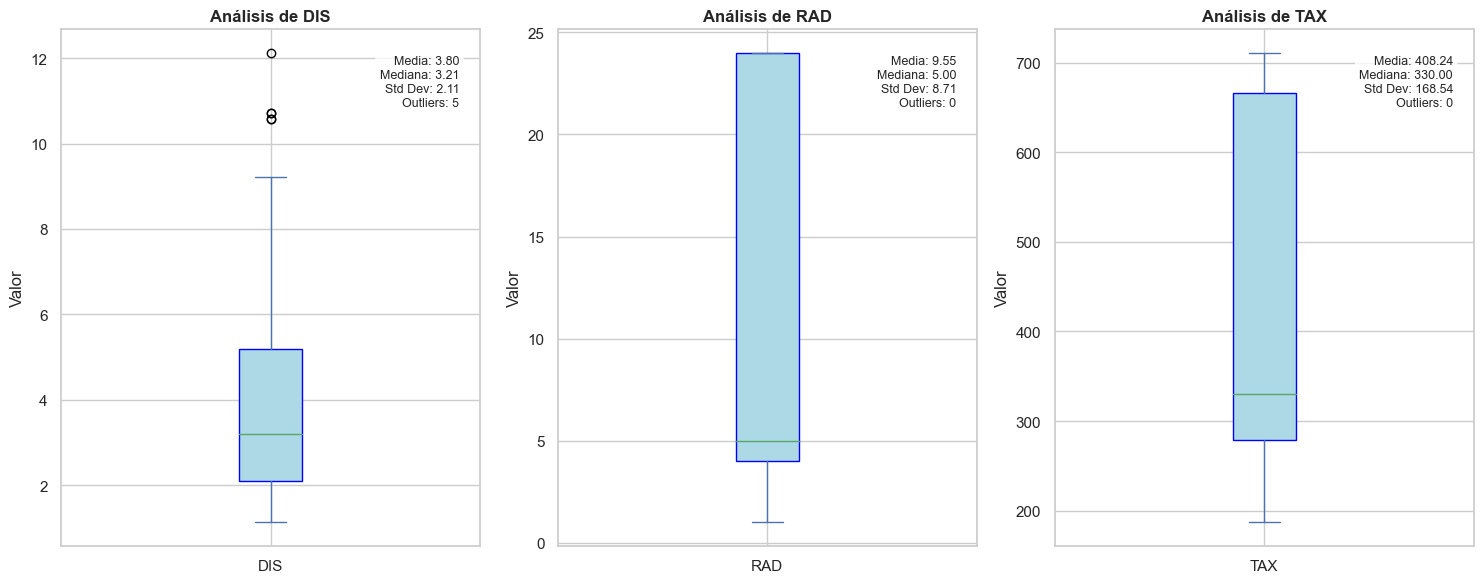

In [223]:
variables = ['DIS', 'RAD', 'TAX']
outlier_analysis_boxplots(variables)

| Variable | Tipo de Outlier | Estrategia Recomendada en Pipeline |
|---|---:|---|
| DIS | Valor extremo real | No hacer nada, solo son 5 datos |

In [224]:
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("DIS")
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("RAD")
eda_config["feature_processing"]["handling_outliers"]["no_action"].append("TAX")

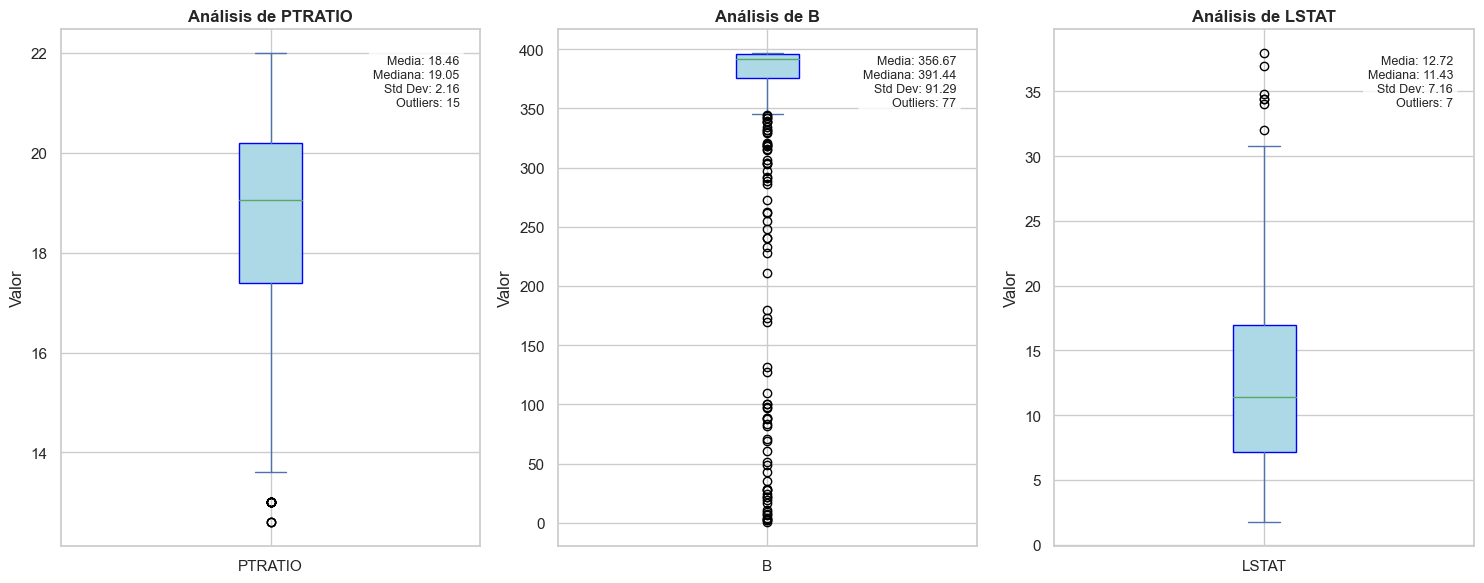

In [225]:
variables = ['PTRATIO', 'B', 'LSTAT']
outlier_analysis_boxplots(variables)

| Variable | Tipo de Outlier | Estrategia Recomendada en Pipeline |
|---|---:|---|
| PTRATIO | Valor extremo real (simétrico/normal) | Capping (Winsorization) o RobustScaler |
| B | Valor extremo real con sesgo severo (asimétrico a la izquierda) | Capping (Winsorization) |
| LSTAT | Valor extremo real con sesgo severo (asimétrico a la derecha) | Transformación logarítmica (np.log1p) |

In [226]:
eda_config["feature_processing"]["handling_outliers"]["capping_winsor"].append("PTRATIO")
eda_config["feature_processing"]["handling_outliers"]["capping_iqr"].append("B")
eda_config["feature_processing"]["handling_outliers"]["log_transform"].append("LSTAT")

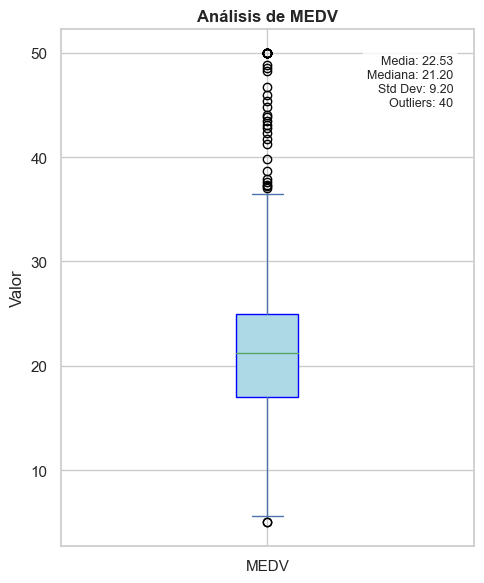

In [227]:
variables = ['MEDV']
outlier_analysis_boxplots(variables)

| Variable | Tipo de Outlier | Estrategia Recomendada en Pipeline |
|---|---:|---|
| MEDV (target)| Valor extremo real con sesgo severo (asimétrico a la derecha) | Utilizar modelos basados en árboles (Random Forest o LightGBM) que no son muy sensibles a outliers reales |

In [228]:
eda_config["model_selection"]["candidates"].extend(["RandomForestRegressor", "XGBRegressor", "LGBMRegressor"])


## Análisis de correlación

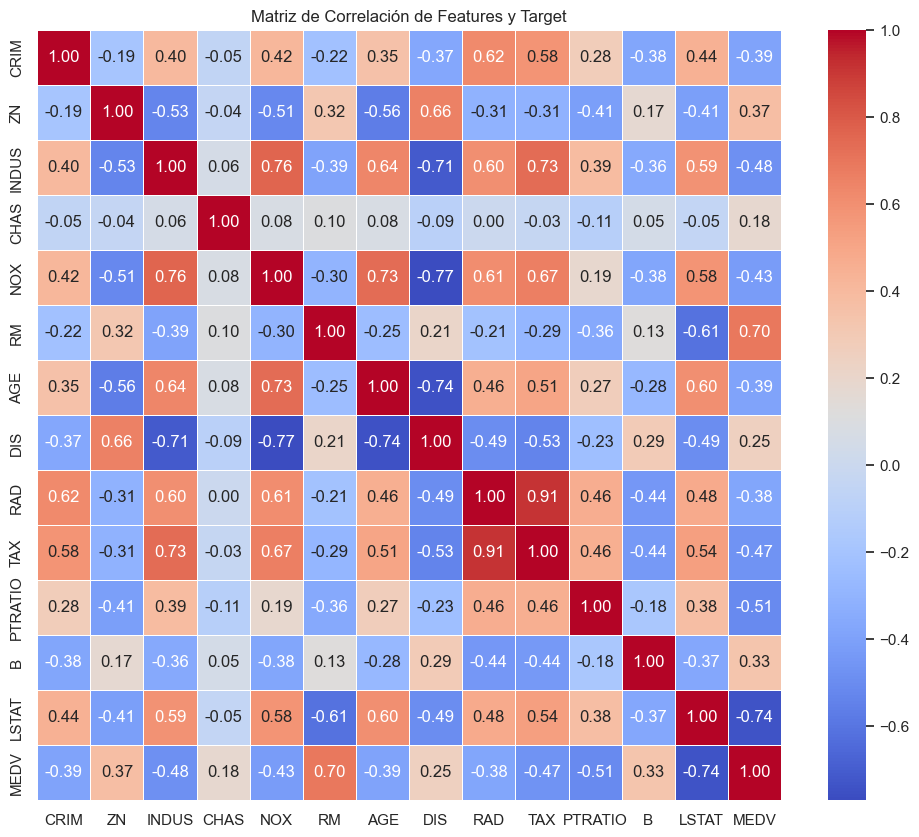

In [229]:
import seaborn as sns

# Supongamos que 'df' es tu DataFrame con todas las variables numéricas y el target 'MEDV'

plt.figure(figsize=(12, 10))
# Calcula la matriz de correlación de Pearson
correlation_matrix = df.corr(numeric_only=True) 

# Usa un heatmap para visualizarla fácilmente
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Features y Target')
plt.show()


Conclusión técnica
- Candidatas a eliminación por alta correlación inter-variable: TAX y RED.Ambas están fuertemente correlacionadas entre sí; RED es la candidata preferente a eliminar porque muestra menor correlación con MEDV que TAX.
- No se recomienda eliminar ninguna otra variable únicamente por correlación, puesto que todas presentan alguna asociación relevante con MEDV.



In [230]:
columns_to_remove = ['RAD', 'B']
eda_config["feature_processing"]["handling_correlated_features"]["remove"].extend(columns_to_remove)

columns_to_keep = [col for col in df.columns if col not in columns_to_remove]
eda_config["feature_processing"]["handling_correlated_features"]["no_action"].extend(columns_to_keep)

NOTA: Se decide eliminar arbitrariamente la columna B por motivo éticos.

'B': The proportion of Black people by town.

In [ ]:
# Crear el campo baseline en el diccionario
eda_config['feature_engineering'] = {
    'domain_features': True,
    'interactions': [],
}

In [234]:
eda_config

{'feature_processing': {'handling_na': {'mean': [],
   'median': ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT'],
   'most_frequent': ['CHAS'],
   'no_action': ['NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'MEDV']},
  'handling_outliers': {'remove': [],
   'log_transform': ['CRIM', 'ZN', 'LSTAT'],
   'capping_iqr': ['RM', 'B'],
   'capping_winsor': ['PTRATIO'],
   'no_action': ['INDUS', 'NOX', 'AGE', 'DIS', 'RAD', 'TAX']},
  'handling_correlated_features': {'remove': ['RAD', 'B'],
   'no_action': ['CRIM',
    'ZN',
    'INDUS',
    'CHAS',
    'NOX',
    'RM',
    'AGE',
    'DIS',
    'TAX',
    'PTRATIO',
    'LSTAT',
    'MEDV']},
  'scaler': 'RobustScaler'},
 'model_selection': {'candidates': ['RandomForestRegressor',
   'XGBRegressor',
   'LGBMRegressor']},
 'feature_engineering': {'domain_features': True, 'interactions': []}}

In [235]:
import yaml

with open('../src/configs/preprocessing_config.yaml', 'w', encoding='utf-8') as fh:
    yaml.dump(eda_config, fh, 
              default_flow_style=False,  # Formato legible (no inline)
              sort_keys=False,            # Mantiene el orden del diccionario
              indent=2,                   # Indentación de 2 espacios
              allow_unicode=True)         # Equivalente a ensure_ascii=False

print('✓ Saved configs/preprocessing_config.yaml')


✓ Saved configs/preprocessing_config.yaml
